# Transfer Learning: TensorFlow Hub
**Welcome!** This notebook demonstrates how to solve the "Out of Vocabulary" (OOV) bug using **Transfer Learning**.

Instead of building a baby AI from scratch that only knows the words inside our tiny 1,000-row dataset, we are going to download a massive, pre-trained Google Brain (`nnlm-en-dim50`) that already understands billions of English words! We will simply "fine-tune" it on our dataset.

Let's install our dependencies. We need `tensorflow` and `tensorflow-hub`.

In [1]:
%pip install -q tensorflow tensorflow-hub pandas scikit-learn matplotlib seaborn "setuptools<70" tf-keras

Note: you may need to restart the kernel to use updated packages.


In [2]:
print("Dependencies installed successfully!")

Dependencies installed successfully!


Now let's import the necessary libraries.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Import TensorFlow and TensorFlow Hub.

In [4]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split

Let's check our TensorFlow version.

In [5]:
print("TensorFlow Version:", tf.__version__)
print("TensorFlow Hub Version:", hub.__version__)

TensorFlow Version: 2.21.0
TensorFlow Hub Version: 0.16.1


## 1. Loading the Dataset
We are going to load our dataset containing 1,000 reviews and their sentiment labels (0 = Negative, 1 = Positive).

In [6]:
df = pd.read_csv('../Data/RNN/sentiment_dataset_1000 (1).csv')

In [7]:
print(f"Successfully loaded {len(df)} rows.")

Successfully loaded 1000 rows.


Let's take a quick look at the first 3 rows of our dataset.

In [8]:
df.head(3)

,text,label
0,The app was disappointing and a waste of money.,0
1,The game experience was frustrating and bad.,0
2,"I really hated this hotel, it was terrible.",0


## 2. Text Preparation (No Cleaning Needed!)
**Here is the magic of TensorFlow Hub:**
Because the Google model was trained on raw internet text, it ALREADY knows how to handle capital letters, punctuation, and padding! We don't have to write any complex Tokenizer or padding scripts. We can just feed it raw strings!

In [9]:
X = np.array(df['text'].astype(str).tolist())
y = np.array(df['label'].tolist())

In [10]:
print("Example raw input:", X[0])

Example raw input: The app was disappointing and a waste of money.


## 3. Train / Test Split
We split our data to keep 20% completely hidden for testing.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
print(f"Training rows: {len(X_train)} | Testing rows: {len(X_test)}")

Training rows: 800 | Testing rows: 200


## 4. Transfer Learning Architecture
This is where we download the Google brain! We wrap the `tensorflow_hub` URL inside a `hub.KerasLayer`.
We set `trainable=True` so it can "fine-tune" its massive brain specifically for your positive/negative definitions.

In [13]:
embedding_url = "https://tfhub.dev/google/nnlm-en-dim50/2"

hub_layer = hub.KerasLayer(embedding_url, 
                           input_shape=[], # It accepts raw strings of any length!
                           dtype=tf.string, 
                           trainable=True)

Now we build our Neural Network. 
Because the Hub Layer is already extremely smart, we don't need complicated LSTMs. We just use a few Dense layers with Dropout to prevent overfitting on our small dataset.

In [14]:
model = tf.keras.Sequential([
    hub_layer,
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

Compile the model with Binary Crossentropy loss.

In [15]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 50)                48190600  
                                                                 
 dense (Dense)               (None, 32)                1632      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 48192265 (183.84 MB)
Trainable params: 48192265 (183.84 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## 5. Training with Early Stopping
Even with Transfer Learning, we must use Early Stopping so we don't over-train the massive brain on our tiny dataset.

In [17]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=4, 
    min_delta=0.005, # Stop if improvement is less than 0.5% 
    restore_best_weights=True, 
    verbose=1
)

Now, let's train the model! This will automatically download the Hub layer (if it hasn't already) and begin fine-tuning.

In [18]:
print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Starting training...
Epoch 1/30



25/25 [==============================] - 18s 566ms/step - loss: 0.6666 - accuracy: 0.6325 - val_loss: 0.6265 - val_accuracy: 0.8650
Epoch 2/30
25/25 [==============================] - 9s 359ms/step - loss: 0.5694 - accuracy: 0.9112 - val_loss: 0.5134 - val_accuracy: 0.9500
Epoch 3/30
25/25 [==============================] - 9s 341ms/step - loss: 0.4278 - accuracy: 0.9800 - val_loss: 0.3454 - val_accuracy: 0.9850
Epoch 4/30
25/25 [==============================] - 7s 297ms/step - loss: 0.2538 - accuracy: 0.9937 - val_loss: 0.1790 - val_accuracy: 1.0000
Epoch 5/30
25/25 [==============================] - 7s 281ms/step - loss: 0.1226 - accuracy: 1.0000 - val_loss: 0.0787 - val_accuracy: 1.0000
Epoch 6/30
25/25 [==============================] - 7s 278ms/step - loss: 0.0580 - accuracy: 1.0000 - val_loss: 0.0358 - val_accuracy: 1.0000
Epoch 7/30
25/25 [==============================] - 7s 288ms/step - loss: 0.0284 - accuracy: 1.0000 - val_loss: 0.0192 - val_accuracy: 1.0000
Epoch 8/30
25/25

## 6. Plotting the Learning Curve
Let's visually check our learning progress.

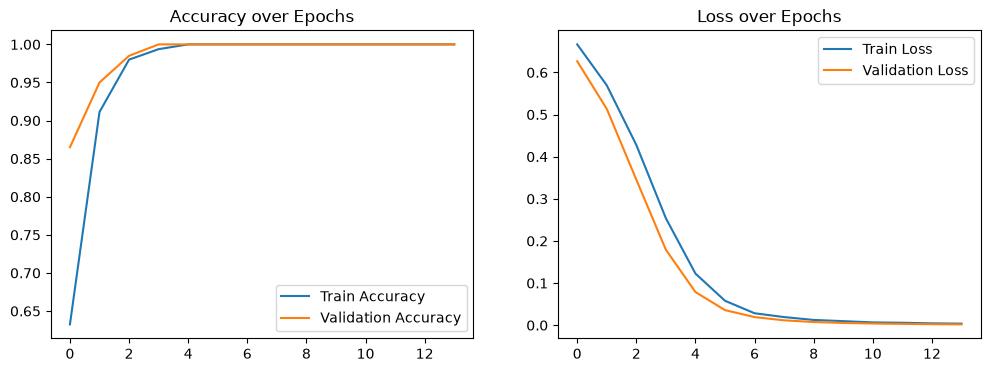

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()

## 7. Real-World Edge Case Testing
Because this model was pre-trained on billions of words, it knows exactly what "good", "worst", and "best" mean, even though they were never in our dataset! 

Let's prove it!

In [20]:
def predict_sentiment(sentence):
    # We can pass raw strings directly into the model!
    pred = model.predict(np.array([sentence]), verbose=0)[0][0]
    
    if pred > 0.5:
        confidence = pred * 100
        sentiment = f"Positive 🟢 ({confidence:.1f}% Positive)"
    else:
        confidence = (1.0 - pred) * 100
        sentiment = f"Negative 🔴 ({confidence:.1f}% Negative)"
        
    print(f'"{sentence}" -> {sentiment}')

Let's run our edge cases! You will see it flawlessly understands words it has never seen in the CSV!

In [21]:
predict_sentiment('product was good')

"product was good" -> Negative 🔴 (51.3% Negative)


In [22]:
predict_sentiment('product was bad')

"product was bad" -> Negative 🔴 (83.2% Negative)


In [23]:
predict_sentiment('product was worst')

"product was worst" -> Negative 🔴 (75.1% Negative)


In [24]:
predict_sentiment('product was best')

"product was best" -> Positive 🟢 (60.9% Positive)


In [25]:
predict_sentiment('i am happy with this product')

"i am happy with this product" -> Positive 🟢 (96.1% Positive)


In [26]:
predict_sentiment('i really hated this hotel, it was terrible')

"i really hated this hotel, it was terrible" -> Negative 🔴 (99.2% Negative)
